Image Source - (https://www.deeplearning.ai/)

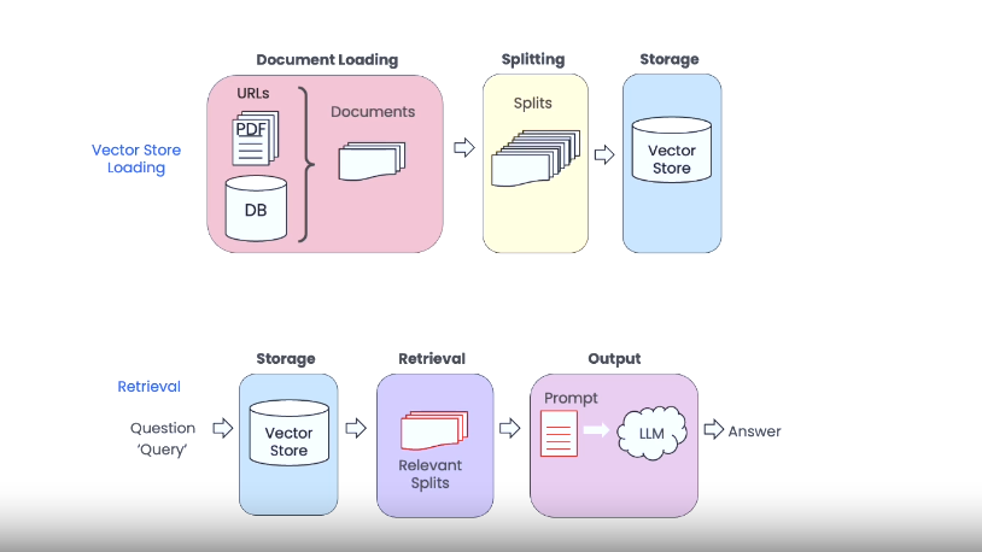

In [1]:
!pip install -q langchain langchain-openai langchain-community langchain-core langchain-text-splitters faiss-cpu PyPDF2 tiktoken


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPEN_API_KEY')


In [3]:
from google.colab import files

print("Please upload your PDF file...")
uploaded = files.upload()

# Take the first uploaded file
pdf_path = list(uploaded.keys())[0]
print(f"Using PDF: {pdf_path}")


Please upload your PDF file...


Saving LARGE LANGUAGE MODELS IN THE 6GENABLED COMPUTING CONTINUUM (1) (4).pdf to LARGE LANGUAGE MODELS IN THE 6GENABLED COMPUTING CONTINUUM (1) (4).pdf
Using PDF: LARGE LANGUAGE MODELS IN THE 6GENABLED COMPUTING CONTINUUM (1) (4).pdf


In [4]:
from typing import List
from PyPDF2 import PdfReader

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough


/tmp/ipykernel_699/105131754.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [5]:
def load_pdf_text(pdf_path: str) -> str:
    """Read all text from a PDF file."""
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        content = page.extract_text()
        if content:
            text += content
    if not text.strip():
        raise ValueError("No text extracted from PDF. Is it a scanned/image-only PDF?")
    return text


def split_text(raw_text: str) -> List[str]:
    """Split raw text into overlapping chunks."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,
        chunk_overlap=200,
    )
    return splitter.split_text(raw_text)


def build_vectorstore(chunks: List[str]) -> FAISS:
    """Build a FAISS vector store using OpenAI embeddings."""
    embeddings = OpenAIEmbeddings()
    vectorstore = FAISS.from_texts(chunks, embeddings)
    return vectorstore


In [6]:
def build_rag_chain(vectorstore: FAISS):
    """Create a Retrieval-Augmented Generation chain over the vector store."""
    retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
    llm = ChatOpenAI(
        model="gpt-4o-mini",   # change if you want another model
        temperature=0
    )
    prompt = ChatPromptTemplate.from_template(
        """
You are a helpful assistant that answers questions ONLY using the provided context.
If the answer is not in the context, say "I can't find this in the PDF" instead of guessing.
Context:
{context}
Question:
{question}

Answer in simple, clear language:
"""
    )
    # RAG chain: question → retrieve → format prompt → LLM
    rag_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
    )
    return rag_chain


In [7]:
if "OPENAI_API_KEY" not in os.environ:
    raise EnvironmentError("OPENAI_API_KEY not set. Run the API key cell first.")

print(f"Loading PDF from: {pdf_path}")
raw_text = load_pdf_text(pdf_path)
print(f"PDF loaded. Text length: {len(raw_text)} characters")

print("Splitting text into chunks...")
chunks = split_text(raw_text)
print(f"Created {len(chunks)} chunks")

print("Building vector store...")
vectorstore = build_vectorstore(chunks)
print("Vector store ready.")

print("Creating RAG chain...")
rag = build_rag_chain(vectorstore)

print("\n✅ Setup complete. Use chat_with_pdf() in the next cell to ask questions.")


Loading PDF from: LARGE LANGUAGE MODELS IN THE 6GENABLED COMPUTING CONTINUUM (1) (4).pdf
PDF loaded. Text length: 291059 characters
Splitting text into chunks...
Created 482 chunks
Building vector store...
Vector store ready.
Creating RAG chain...

✅ Setup complete. Use chat_with_pdf() in the next cell to ask questions.


In [8]:
def chat_with_pdf(question: str):
    """Ask a question about the uploaded PDF."""
    try:
        response = rag.invoke(question)
        # response is a ChatMessage
        print("Assistant:\n", response.content)
    except Exception as e:
        print("Error:", e)

# Example:
# chat_with_pdf("Summarise the main idea of this document in simple terms.")


In [9]:
chat_with_pdf("What this pdf is all about?")


Assistant:
 The PDF is a white paper that explores the topic of 6G technologies. It reviews existing knowledge, proposes new directions for research and development, and provides insights to guide future efforts in this field. The paper addresses challenges related to the integration of AI models with 6G and discusses the need for clearer standards and regulations.


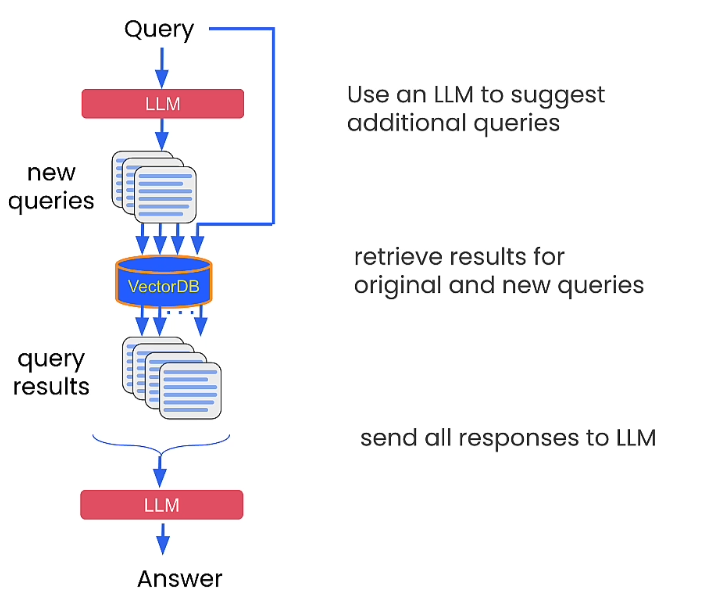

## **Query Expansion (Multi-Query Generation)**

### **Why Query Expansion?**
Standard RAG relies on semantic vector similarity search using only the user's raw question. However:
- The user's query might be phrased differently from the terminology used in the PDF document.
- The query might be short, ambiguous, or miss key technical terms (e.g., asking about *'security issues'* when the document discusses *'zero-trust architecture and cryptographic integrity'*).

### **How It Works (as illustrated in the diagram above):**
1. **Query Generation**: Use an LLM (`gpt-4o-mini`) to generate multiple (e.g. 3-5) diverse formulations/perspectives of the original user question.
2. **Multi-Query Retrieval**: Query the FAISS vector database with the original query **plus** all generated queries.
3. **Deduplication**: Aggregate all retrieved text chunks and remove duplicates based on their text content.
4. **Grounded Generation**: Pass all unique, high-relevance chunks as unified context to the LLM to generate the final grounded response.

In [10]:
from typing import List, Tuple
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.documents import Document

# 1. Prompt template for generating query variations
query_expansion_prompt = ChatPromptTemplate.from_template(
    """You are an AI language model assistant. Your task is to generate {num_queries}
different versions of the given user question to retrieve relevant documents from a vector database.
By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search.
Provide these alternative questions separated by newlines.
Do not number the questions or add any introductory or concluding text.

Original question: {question}"""
)


def generate_expanded_queries(question: str, num_queries: int = 3) -> List[str]:
    """Generate multiple perspectives / reformulations of the original query."""
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
    expansion_chain = query_expansion_prompt | llm | StrOutputParser()
    result = expansion_chain.invoke({"question": question, "num_queries": num_queries})
    # Split by newline and remove empty lines
    queries = [q.strip() for q in result.strip().split("\n") if q.strip()]
    return queries


def retrieve_with_query_expansion(
    question: str,
    vectorstore: FAISS,
    num_queries: int = 3,
    k_per_query: int = 3
) -> Tuple[List[Document], List[str]]:
    """
    Retrieve documents for the original query and its generated variations,
    then deduplicate the result set (union of documents).
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k_per_query})

    # Step 1: Generate alternative queries
    expanded_queries = generate_expanded_queries(question, num_queries=num_queries)
    all_queries = [question] + expanded_queries

    # Step 2: Retrieve and deduplicate chunks
    unique_docs = []
    seen_contents = set()

    for q in all_queries:
        docs = retriever.invoke(q)
        for doc in docs:
            # Deduplicate by chunk text content
            if doc.page_content not in seen_contents:
                seen_contents.add(doc.page_content)
                unique_docs.append(doc)

    return unique_docs, all_queries


def build_query_expansion_rag_chain():
    """Prompt and LLM chain for final answer generation."""
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = ChatPromptTemplate.from_template(
        """You are a helpful assistant that answers questions ONLY using the provided context.
If the answer is not in the context, say \"I can't find this in the PDF\" instead of guessing.

Context:
{context}

Question:
{question}

Answer in simple, clear language:
"""
    )
    return prompt | llm


def chat_with_pdf_query_expansion(
    question: str,
    num_queries: int = 3,
    k_per_query: int = 3,
    verbose: bool = True
):
    """
    Complete end-to-end function for asking questions using Query Expansion.
    """
    try:
        # Retrieve unique chunks across all query variations
        unique_docs, all_queries = retrieve_with_query_expansion(
            question=question,
            vectorstore=vectorstore,
            num_queries=num_queries,
            k_per_query=k_per_query
        )

        if verbose:
            print("=" * 70)
            print(f"🔍 Original Query:\n   {question}\n")
            print(f"💡 Generated Alternate Queries ({len(all_queries)-1}):")
            for i, q in enumerate(all_queries[1:], 1):
                print(f"   {i}. {q}")
            print(f"\n📚 Total Unique Chunks Retrieved (Deduplicated): {len(unique_docs)}")
            print("=" * 70)

        # Build context from unique retrieved chunks
        context_text = "\n\n".join([doc.page_content for doc in unique_docs])

        # Generate grounded response
        rag_chain = build_query_expansion_rag_chain()
        response = rag_chain.invoke({
            "context": context_text,
            "question": question
        })

        print("\n🤖 Assistant:\n", response.content)
        return response

    except Exception as e:
        print("Error:", e)

print("✅ Query Expansion pipeline functions defined successfully.")

✅ Query Expansion pipeline functions defined successfully.


In [11]:
# Alternative: Using LangChain's built-in MultiQueryRetriever
# Note: Requires the main 'langchain' package (!pip install -q langchain)
try:
    from langchain.retrievers.multi_query import MultiQueryRetriever

    # Initialize LangChain's MultiQueryRetriever
    multi_query_retriever = MultiQueryRetriever.from_llm(
        retriever=vectorstore.as_retriever(search_kwargs={"k": 3}),
        llm=ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
    )

    # Build RAG chain with MultiQueryRetriever
    multi_query_rag_chain = (
        {"context": multi_query_retriever, "question": RunnablePassthrough()}
        | ChatPromptTemplate.from_template(
            """You are a helpful assistant that answers questions ONLY using the provided context.
If the answer is not in the context, say \"I can't find this in the PDF\" instead of guessing.

Context:
{context}

Question:
{question}

Answer in simple, clear language:
"""
        )
        | ChatOpenAI(model="gpt-4o-mini", temperature=0)
    )
    print("✅ MultiQueryRetriever chain built successfully.")
except ImportError:
    print("⚠️ 'langchain' package not found. Run '!pip install -q langchain' to use MultiQueryRetriever.")
    print("ℹ️ Note: The custom Query Expansion implementation in Cell 14 works out of the box with langchain-core!")


⚠️ 'langchain' package not found. Run '!pip install -q langchain' to use MultiQueryRetriever.
ℹ️ Note: The custom Query Expansion implementation in Cell 14 works out of the box with langchain-core!


In [13]:
# Test query with Query Expansion
sample_query = "What this pdf is all about?"
chat_with_pdf_query_expansion(sample_query, num_queries=3, k_per_query=3, verbose=True)

🔍 Original Query:
   What this pdf is all about?

💡 Generated Alternate Queries (3):
   1. Can you summarize the main topics covered in this PDF?
   2. What are the key points discussed in this document?
   3. What is the overall purpose and content of this PDF file?

📚 Total Unique Chunks Retrieved (Deduplicated): 4

🤖 Assistant:
 This PDF is a white paper that explores the topic of 6G technologies. It reviews existing knowledge and suggests new ideas to improve the field. The main goal is to provide a vision for future research and development in 6G, along with practical insights that meet future needs. It also discusses challenges related to standards and regulations in the context of AI models and their integration into mobile networks.


AIMessage(content='This PDF is a white paper that explores the topic of 6G technologies. It reviews existing knowledge and suggests new ideas to improve the field. The main goal is to provide a vision for future research and development in 6G, along with practical insights that meet future needs. It also discusses challenges related to standards and regulations in the context of AI models and their integration into mobile networks.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 479, 'total_tokens': 557, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d3ba5542b', 'id': 'chatcmpl-ETNekFtmaX3TieztbQCcbnvzMW8gd', 'service_tier': 'default', 'finis

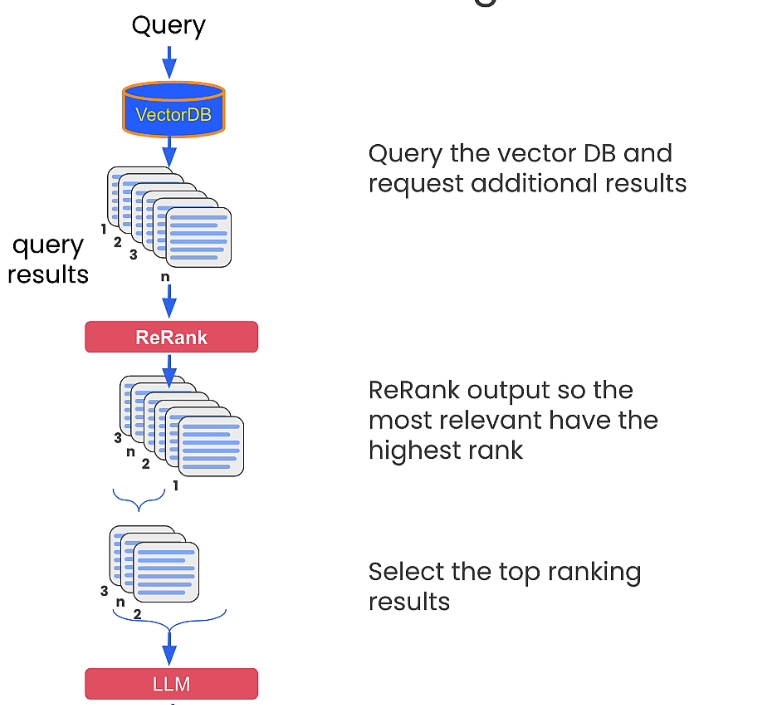